# Parte 1 — Exploração dos dados e pré-processamento\n\n**Checkpoint Cientista de Dados N3 — Classificação de fraturas ósseas**\n\nUm hospital universitário quer um modelo capaz de classificar o tipo de fratura óssea em exames de raio-X, como apoio à triagem radiológica. Esta primeira etapa organiza o dataset **HBFMID** (Roboflow, formato YOLOv8, 1539 imagens 640x640, 10 classes de fratura), entende sua distribuição e limitações, e define o pré-processamento usado no treino (Parte 2).\n\nO dataset original traz **anotações de detecção** (bounding boxes por classe), não um rótulo único por imagem. Como o objetivo aqui é *classificação da imagem inteira*, a primeira decisão de engenharia é: como derivar um rótulo por imagem a partir das boxes? Isso é resolvido na seção 1."

In [1]:
import sys
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

sys.path.append(str(Path.cwd().parent))
from src.dataset import CLASS_NAMES, build_dataframe, make_dataset, parse_yolo_label

plt.rcParams["figure.dpi"] = 100
DATA_DIR = Path.cwd().parent / "data"
RNG = np.random.default_rng(42)

## 1. Carregando e organizando os dados

O Roboflow já entrega o dataset dividido em `train` / `valid` / `test`, cada split com `images/` e `labels/` (uma anotação `.txt` YOLO por imagem: `classe x_center y_center largura altura`, valores normalizados).

Cada imagem pode ter **mais de uma bounding box**, às vezes de classes diferentes. Como queremos um único rótulo por imagem, a regra usada (`src/dataset.py::majority_class`) é: **classe majoritária entre as boxes da imagem**; empate é resolvido pelo menor `class_id` (regra determinística). Imagens sem nenhuma box são descartadas — não há rótulo confiável para elas.

In [2]:
df = build_dataframe(DATA_DIR)
print(f"Total de imagens rotuladas: {len(df)}")
df.head()

Total de imagens rotuladas: 1536


,filepath,label_path,split,class_id,class_name,n_boxes,n_unique_classes
0,C:\Users\dougl\OneDrive\Área de Trabalho\Claud...,C:\Users\dougl\OneDrive\Área de Trabalho\Claud...,train,8,Transverse Displaced,1,1
1,C:\Users\dougl\OneDrive\Área de Trabalho\Claud...,C:\Users\dougl\OneDrive\Área de Trabalho\Claud...,train,7,Spiral,1,1
2,C:\Users\dougl\OneDrive\Área de Trabalho\Claud...,C:\Users\dougl\OneDrive\Área de Trabalho\Claud...,train,8,Transverse Displaced,1,1
3,C:\Users\dougl\OneDrive\Área de Trabalho\Claud...,C:\Users\dougl\OneDrive\Área de Trabalho\Claud...,train,7,Spiral,1,1
4,C:\Users\dougl\OneDrive\Área de Trabalho\Claud...,C:\Users\dougl\OneDrive\Área de Trabalho\Claud...,train,8,Transverse Displaced,1,1


In [3]:
resumo_split = df.groupby("split").size().reindex(["train", "valid", "test"])
excluidas = {
    split: len(list((DATA_DIR / split / "images").iterdir())) - resumo_split.get(split, 0)
    for split in ["train", "valid", "test"]
}
print("Imagens por split (após excluir as sem nenhuma box):")
print(resumo_split)
print("\nImagens excluídas por falta de anotação:", excluidas)
print("\nImagens com mais de uma classe entre as boxes (casos ambíguos resolvidos por maioria):")
print(df.groupby("split")["n_unique_classes"].apply(lambda s: (s > 1).sum()))

Imagens por split (após excluir as sem nenhuma box):
split
train    1344
valid     128
test       64
dtype: int64

Imagens excluídas por falta de anotação: {'train': np.int64(3), 'valid': np.int64(0), 'test': np.int64(0)}

Imagens com mais de uma classe entre as boxes (casos ambíguos resolvidos por maioria):
split
test      0
train    99
valid    14
Name: n_unique_classes, dtype: int64


## 2. Tamanho do dataset e distribuição de classes

O dataset é pequeno para padrões de deep learning (pouco mais de mil imagens de treino) e, como veremos, **desbalanceado**: algumas classes de fratura são muito mais frequentes que outras.

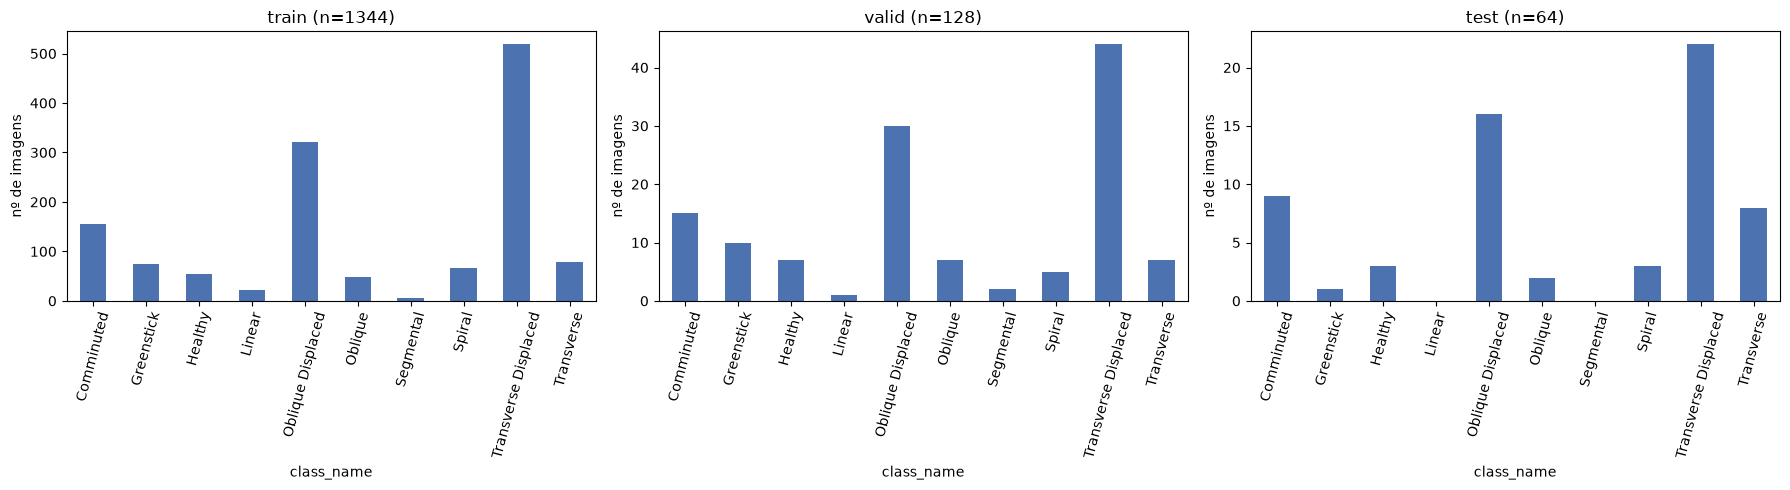

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, split in zip(axes, ["train", "valid", "test"]):
    counts = df[df["split"] == split]["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0)
    counts.plot(kind="bar", ax=ax, color="#4C72B0")
    ax.set_title(f"{split} (n={len(df[df['split'] == split])})")
    ax.set_ylabel("nº de imagens")
    ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

In [5]:
train_counts = df[df["split"] == "train"]["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0)
razao_desbalanceamento = train_counts.max() / train_counts.min()
print("Contagem de imagens de treino por classe:")
print(train_counts)
print(f"\nClasse mais frequente / classe menos frequente: {razao_desbalanceamento:.1f}x")

sem_suporte_teste = [c for c in CLASS_NAMES if (df[(df.split == "test") & (df.class_name == c)].shape[0]) == 0]
print(f"\nClasses sem nenhuma imagem no conjunto de teste oficial: {sem_suporte_teste}")

Contagem de imagens de treino por classe:
class_name
Comminuted              156
Greenstick               75
Healthy                  54
Linear                   21
Oblique Displaced       321
Oblique                  48
Segmental                 6
Spiral                   66
Transverse Displaced    519
Transverse               78
Name: count, dtype: int64

Classe mais frequente / classe menos frequente: 86.5x

Classes sem nenhuma imagem no conjunto de teste oficial: ['Linear', 'Segmental']


## 3. Quantas imagens *originais* existem de fato?

O README do Roboflow (`data/README.roboflow.txt`) revela que este dataset de 1539 imagens foi **gerado por data augmentation** a partir de um conjunto bem menor de raios-X originais (flip, rotação leve, shear, brilho). Os nomes de arquivo preservam isso: `<id-base>.rf.<hash>.jpg` — o mesmo `<id-base>` se repete em várias cópias aumentadas.

Isso importa muito para a divisão em train/valid/test: se cópias aumentadas da *mesma* imagem original caírem em splits diferentes, o modelo pode "ver" no treino uma versão quase idêntica à que será avaliada na validação/teste — inflando as métricas.

In [6]:
df["base_id"] = df["filepath"].apply(lambda p: Path(p).stem.split(".rf.")[0])

bases_por_split = df.groupby("split")["base_id"].apply(set)
print("Imagens totais x imagens-base únicas, por split:")
for split in ["train", "valid", "test"]:
    n_total = (df["split"] == split).sum()
    n_base = len(bases_por_split[split])
    print(f"  {split:6s}: {n_total:4d} imagens vindas de {n_base:3d} raios-X originais únicos")

overlap_tv = bases_por_split["train"] & bases_por_split["valid"]
overlap_tt = bases_por_split["train"] & bases_por_split["test"]
overlap_vt = bases_por_split["valid"] & bases_por_split["test"]
print(f"\nImagens-base compartilhadas entre train e valid: {len(overlap_tv)}")
print(f"Imagens-base compartilhadas entre train e test:  {len(overlap_tt)}")
print(f"Imagens-base compartilhadas entre valid e test:  {len(overlap_vt)}")
print(f"\nTotal de raios-X originais únicos no dataset inteiro: {df['base_id'].nunique()}")

Imagens totais x imagens-base únicas, por split:
  train : 1344 imagens vindas de 213 raios-X originais únicos
  valid :  128 imagens vindas de  90 raios-X originais únicos
  test  :   64 imagens vindas de  59 raios-X originais únicos

Imagens-base compartilhadas entre train e valid: 70
Imagens-base compartilhadas entre train e test:  47
Imagens-base compartilhadas entre valid e test:  19

Total de raios-X originais únicos no dataset inteiro: 244


In [7]:
# Por que não simplesmente re-agrupar o split por imagem-base (GroupShuffleSplit)
# e eliminar o vazamento? Porque, nesse nível, algumas classes têm pouquíssimos
# raios-X originais distintos — não dá para garantir as 3 partições sem zerar
# alguma classe rara.
base_majority = df.drop_duplicates("base_id").groupby("class_name")["base_id"].count().reindex(CLASS_NAMES)
print("Nº de raios-X ORIGINAIS únicos por classe (1 amostra por base_id):")
print(base_majority.sort_values())

Nº de raios-X ORIGINAIS únicos por classe (1 amostra por base_id):
class_name
Segmental                2
Linear                   5
Healthy                  5
Oblique                  7
Spiral                  10
Greenstick              11
Transverse              11
Oblique Displaced       50
Comminuted              56
Transverse Displaced    87
Name: base_id, dtype: int64


**Decisão de pré-processamento:** dado esse impasse (vazamento vs. inviabilidade de um split agrupado e estratificado), optamos por **manter o split oficial train/valid/test do Roboflow** — é a organização que os dados fornecem, e reparticionar do zero exigiria descartar ou fundir classes raras. Em troca, fica documentado aqui, de forma explícita, que **as métricas de validação/teste da Parte 2 tendem a superestimar a generalização real do modelo**, porque parte das imagens de validação/teste são variações aumentadas de fotos que o modelo já viu (de forma diferente) no treino. Essa é a limitação mais importante do projeto.

## 4. Exemplos visuais por classe

Um grid com alguns exemplos de cada uma das 10 classes, com as bounding boxes originais desenhadas (em vermelho) para dar contexto de onde está a fratura anotada.

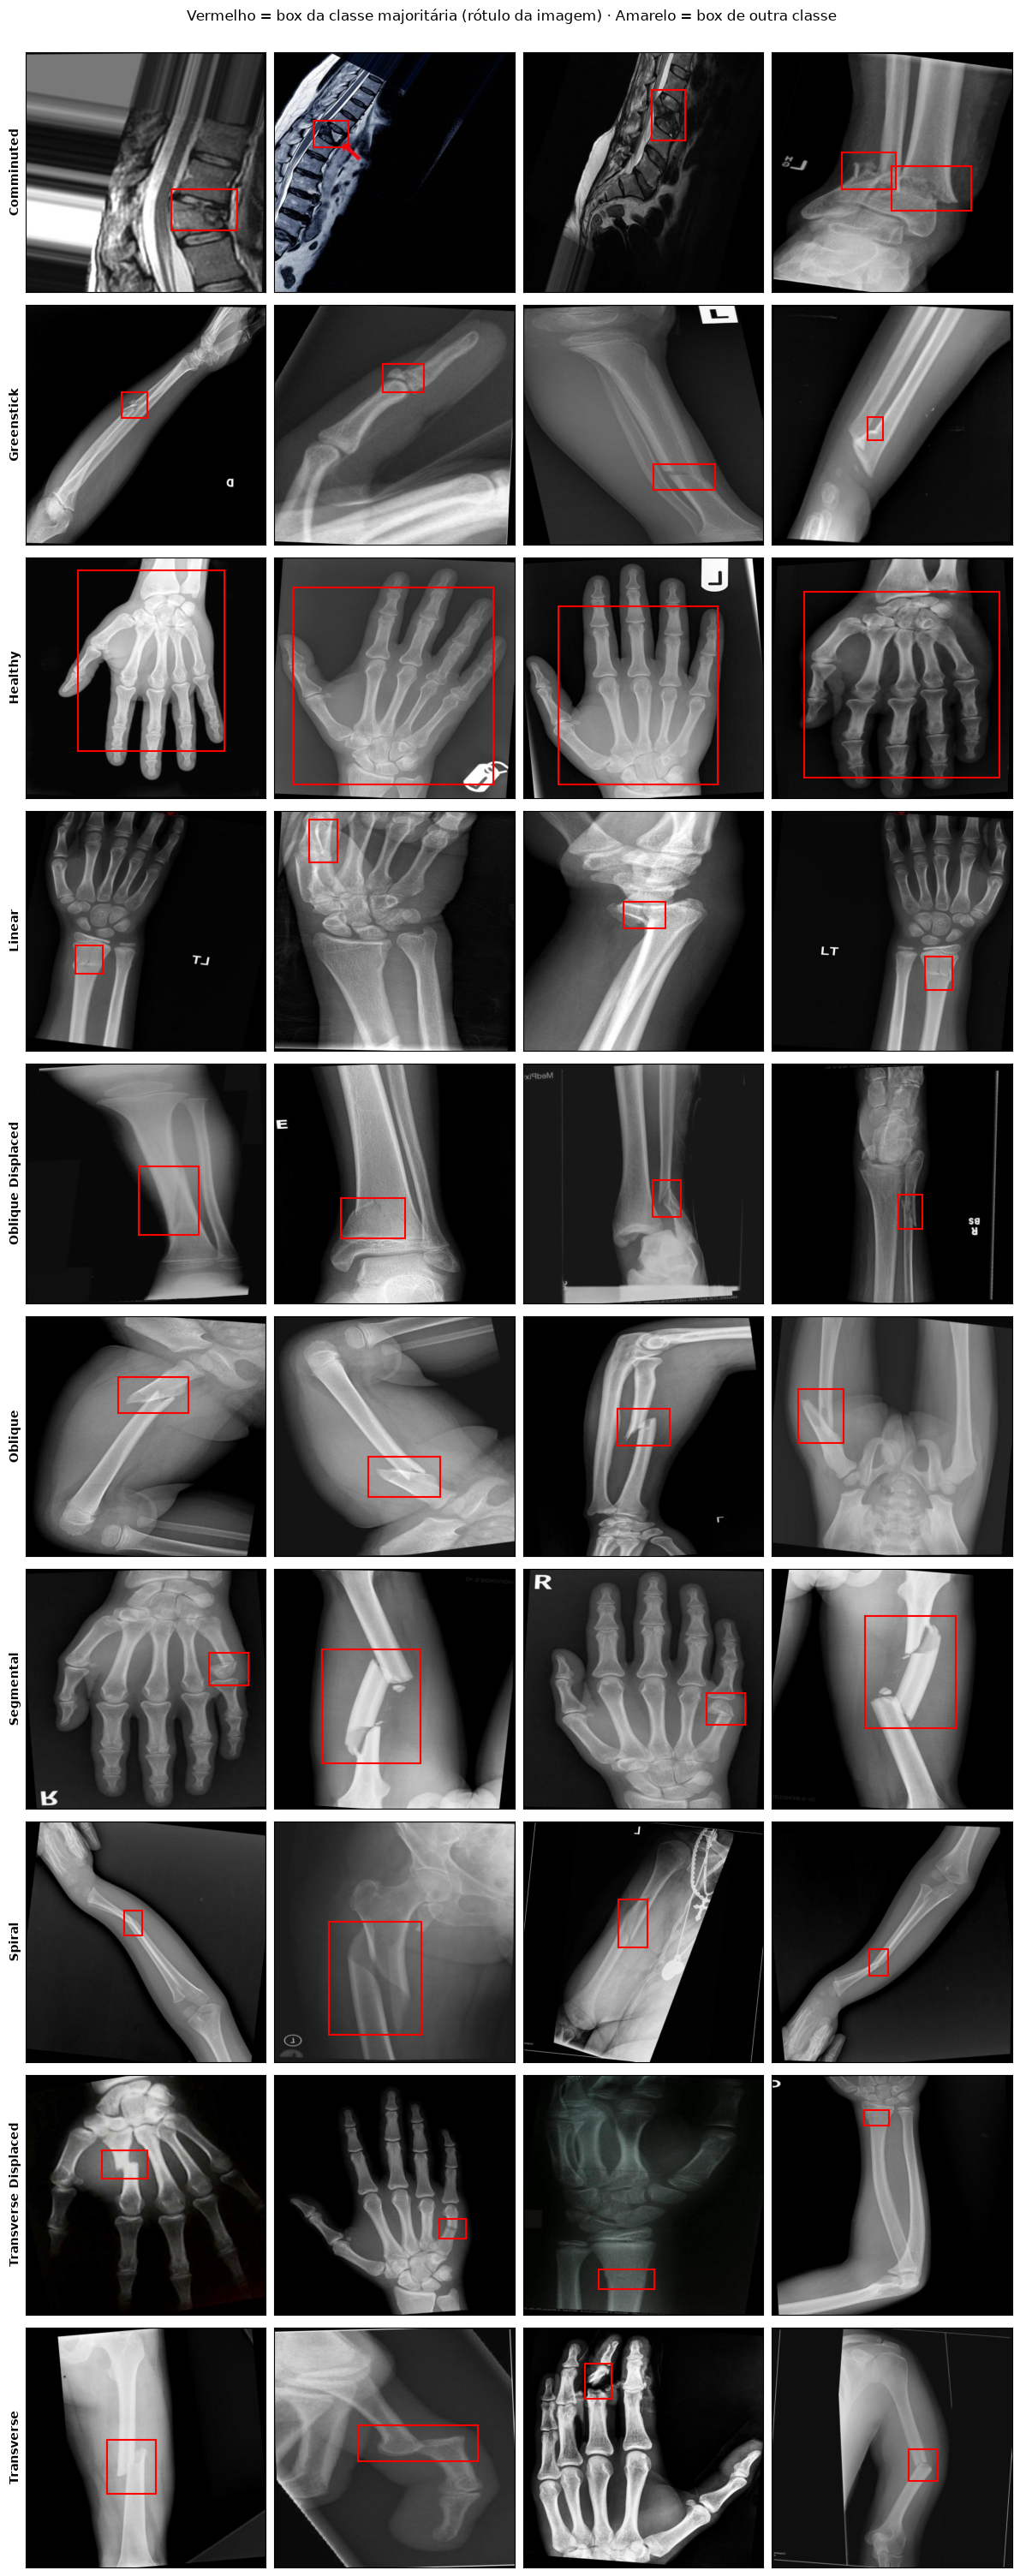

In [8]:
def show_example_grid(df, class_names, n_per_class=4, seed=42):
    fig, axes = plt.subplots(len(class_names), n_per_class, figsize=(3 * n_per_class, 3 * len(class_names)))
    for row, cls in enumerate(class_names):
        subset = df[df.class_name == cls]
        n_show = min(n_per_class, len(subset))
        sample = subset.sample(n=n_show, random_state=seed) if n_show > 0 else subset
        for col in range(n_per_class):
            ax = axes[row, col]
            ax.set_xticks([])
            ax.set_yticks([])
            if col >= n_show:
                ax.axis("off")
                continue
            item = sample.iloc[col]
            image = Image.open(item.filepath).convert("RGB")
            w, h = image.size
            ax.imshow(image)
            for class_id, x, y, bw, bh in parse_yolo_label(Path(item.label_path)):
                color = "red" if class_id == item.class_id else "yellow"
                rect = patches.Rectangle(
                    ((x - bw / 2) * w, (y - bh / 2) * h), bw * w, bh * h,
                    linewidth=1.5, edgecolor=color, facecolor="none",
                )
                ax.add_patch(rect)
            if col == 0:
                ax.set_ylabel(cls, fontsize=10, fontweight="bold")
    fig.suptitle("Vermelho = box da classe majoritária (rótulo da imagem) · Amarelo = box de outra classe", y=1.001)
    plt.tight_layout()
    plt.show()


show_example_grid(df, CLASS_NAMES, n_per_class=4)

## 5. Classes visualmente parecidas

Olhando o grid acima, alguns pares de classes descrevem variações do mesmo tipo de traço de fratura (uma "simples" e uma "com desvio/deslocamento"): **Transverse vs. Transverse Displaced** e **Oblique vs. Oblique Displaced**. A diferença entre elas é sutil (o desvio dos fragmentos ósseos), então é razoável esperar que sejam as classes mais confundidas pelo modelo — vale conferir isso na matriz de confusão da Parte 2.

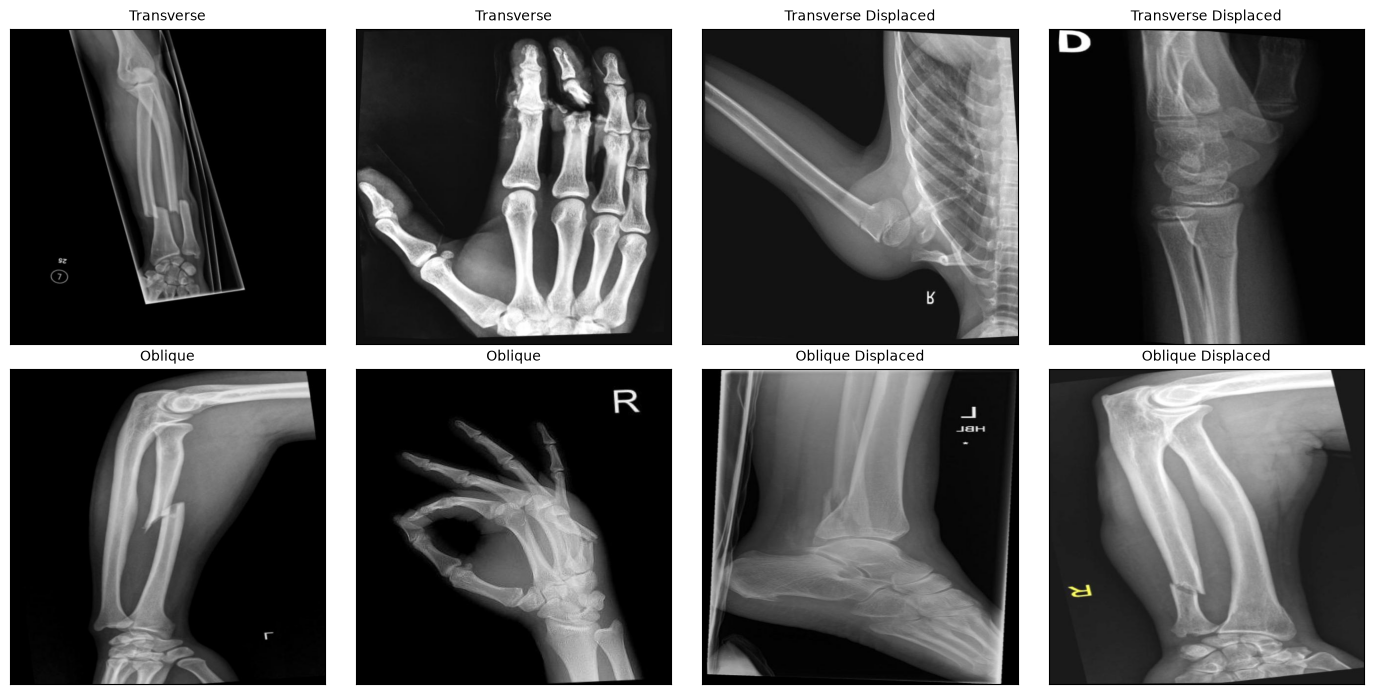

In [9]:
pares_parecidos = [("Transverse", "Transverse Displaced"), ("Oblique", "Oblique Displaced")]
fig, axes = plt.subplots(len(pares_parecidos), 4, figsize=(14, 7))
for row, (cls_a, cls_b) in enumerate(pares_parecidos):
    for col, cls in enumerate([cls_a, cls_a, cls_b, cls_b]):
        subset = df[df.class_name == cls].sample(n=1, random_state=row * 10 + col)
        item = subset.iloc[0]
        image = Image.open(item.filepath).convert("RGB")
        ax = axes[row, col]
        ax.imshow(image)
        ax.set_title(cls, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
plt.tight_layout()
plt.show()

## 6. Pré-processamento

O pipeline de pré-processamento (`src/dataset.py::make_dataset`) faz, para cada imagem:

1. Leitura do arquivo e decodificação JPEG;
2. Redimensionamento de 640×640 para **224×224** (padrão de entrada do MobileNetV2, usado na Parte 2);
3. Conversão para `float32`.

A normalização final (`/255` para a CNN do zero, ou `preprocess_input` do MobileNetV2) **não** é feita aqui — fica embutida na primeira camada de cada modelo (Parte 2), assim o mesmo pipeline de dados serve para as duas arquiteturas sem duplicar código.

Shape do batch: (8, 224, 224, 3) <dtype: 'float32'>
Min/Max de pixel: 0.0 255.0
Rótulos do batch: ['Oblique Displaced', 'Transverse', 'Transverse', 'Transverse Displaced', 'Comminuted', 'Transverse Displaced', 'Oblique', 'Transverse']


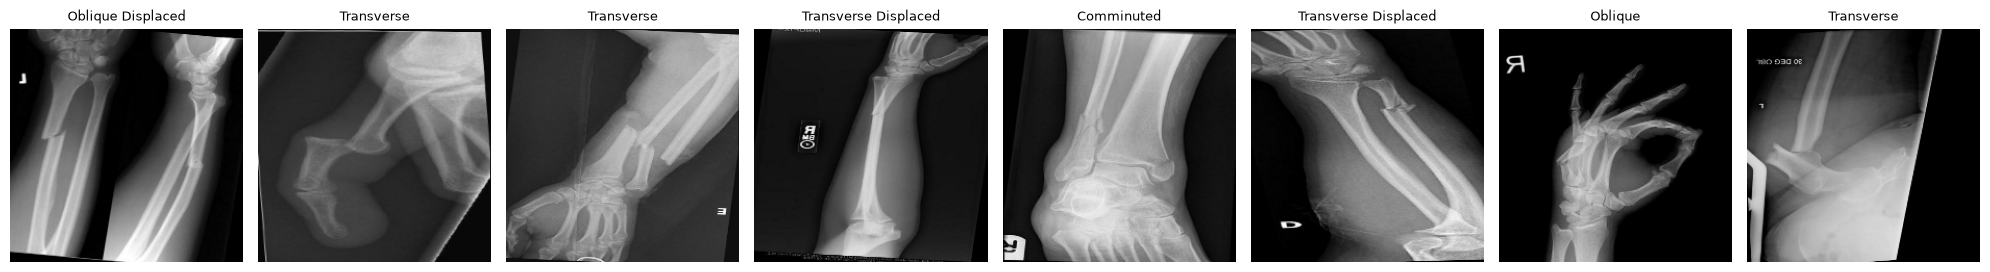

In [10]:
amostra_ds = make_dataset(df, "train", batch_size=8, shuffle=True)
images, labels = next(iter(amostra_ds))
print("Shape do batch:", images.shape, images.dtype)
print("Min/Max de pixel:", float(images.numpy().min()), float(images.numpy().max()))
print("Rótulos do batch:", [CLASS_NAMES[i] for i in labels.numpy()])

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for ax, image, label in zip(axes, images.numpy(), labels.numpy()):
    ax.imshow(image.astype("uint8"))
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Achados e hipóteses para a modelagem

Resumo do que a exploração revelou, e como isso vai orientar a Parte 2:

1. **Dataset pequeno e desbalanceado.** ~1.5 mil imagens no total, mas a classe mais comum de fratura chega a ser dezenas de vezes mais frequente que as mais raras (Linear, Segmental). *Mitigação:* `class_weight` balanceado no treino, além do data augmentation já embutido nos modelos (Parte 2).
2. **Vazamento entre splits.** O dataset "aumentado" de 1539 imagens vem de pouco mais de 200 raios-X originais únicos, e várias dessas imagens-base aparecem em mais de um split. *Consequência:* os números de validação/teste da Parte 2 devem ser lidos como um teto otimista, não como estimativa de generalização em pacientes novos.
3. **Classes sem suporte no teste.** Linear e Segmental não têm nenhuma imagem no split de teste oficial — suas métricas de teste (precision/recall/F1) ficam indefinidas por falta de exemplos, não por erro do modelo.
4. **Classes visualmente parecidas.** Pares como Transverse/Transverse Displaced e Oblique/Oblique Displaced diferem por um detalhe sutil (desvio dos fragmentos) — são a confusão mais esperada na matriz de confusão.
5. **Múltiplas fraturas por imagem.** Uma minoria das imagens tem boxes de mais de uma classe (fraturas em regiões próximas). A regra de classe majoritária resolve isso para a classificação de imagem inteira, mas é uma simplificação que descarta informação — um approach de detecção real capturaria isso melhor.